In [ ]:
import pickle , os
path = '../dataset/pickle/v2/greedy(hybirdnetwork_with_RGBD_collided)/hybird/5q7pvUzZiYa/976.pkl'
# 40576 /29763 / 48780
# Z6MFQCViBuw  , episodeid is 56534
# files = [os.path.join(path , i) for i in os.listdir(path)]

In [3]:
path = '../dataset/pickle/v2/greedy(hybirdnetwork_with_RGBD_train)'
import os
len(os.listdir(path))

52

In [76]:
with open(path , 'rb') as f:
    data = pickle.load(f)

In [7]:
data.keys()

dict_keys(['obs', 'reward', 'done', 'action_id', 'info', 'map', 'path_point', 'sound_id'])

In [72]:
len(data['reward'])

21

In [66]:
len(data['done'])

21

In [74]:
len(data['obs'])

22

In [11]:
len(data['action_id'][0])

7

In [73]:
len(data['action_id'])

22

In [1]:
import torch
torch.cuda.is_available()

True

In [40]:
data['obs'][0].keys()

dict_keys(['rgb', 'depth', 'spectrogram', 'angle'])

(-0.5, 127.5, 127.5, -0.5)

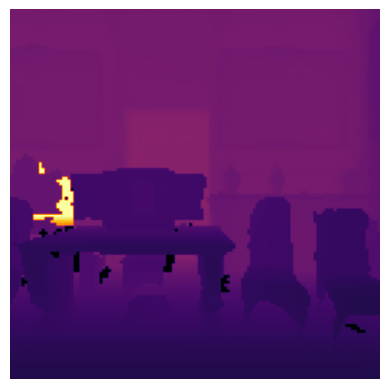

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# assume depth is your (128,128,1) array
depth_2d = np.squeeze(data['obs'][0]['depth'])  # becomes (128,128)

plt.imshow(depth_2d, cmap='inferno')
plt.axis('off')


In [20]:
import numpy as np
np.set_printoptions(suppress=True)

In [21]:
angle = []
for i in range(len(data['obs'])):
    angle.append(np.degrees(data['obs'][i]['angle'][1]))
turn_angle = np.array(angle)

In [48]:
np.remainder(325 + 22.5, 360) // 45

7.0

In [23]:
turn_angle

array([ -90.       ,    0.       ,   90.       ,   99.46232  ,
          9.462321 ,   11.309932 ,   14.0362425,   18.434948 ,
         26.56505  ,   45.       ,   90.       ,   -0.       ,
       -180.       , -180.       ], dtype=float32)

In [7]:
np.degrees(data['obs'][2]['angle'][1])

90.0

In [12]:
import sys
sys.path.append("/home/kongxiangyu/yongzhang/finnal_exp")
from utils.visualizations import plot_top_down_map
from PIL import Image

In [25]:
data['info'][5]['distance_to_goal']

5.0

In [7]:
data['action_id']

[3, 1, 3]

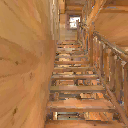

In [10]:
Image.fromarray(data['obs'][0]['rgb'])

In [42]:
data['action_id']

[3, 3, 1]

In [14]:
data['obs'][0]['rgb'].shape

(128, 128, 3)

In [58]:
data['action_id'][7]

2

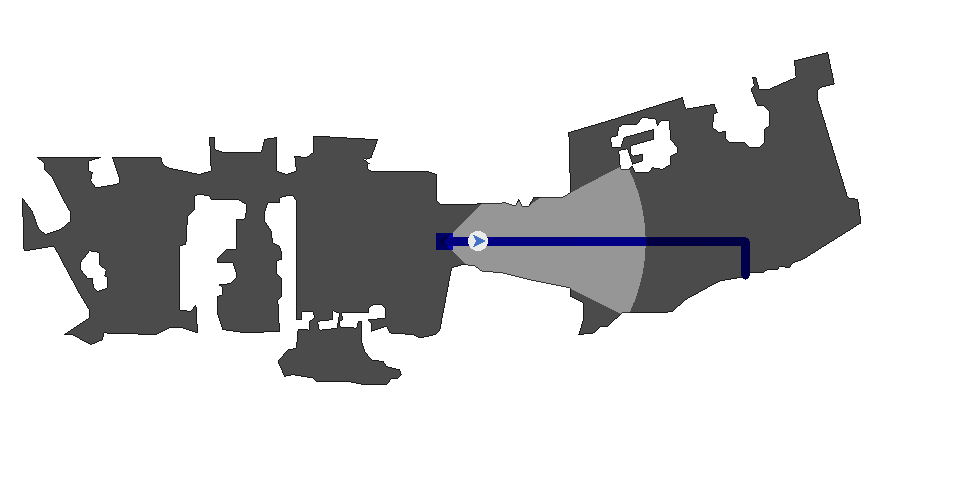

In [77]:
Image.fromarray(plot_top_down_map(data['info'][0]))

In [99]:
data[0][0].keys()

dict_keys(['camera', 'audio', 'step', 'rl_pred', 'rl_logits', 'rl_value', 'reward', 'mask', 'lstm_h', 'lstm_c'])

In [100]:
import numpy as np

In [21]:
def combine_all_audio_data(data, output_path="combined_audio.wav", samplerate=16000):
    """
    将所有 data['obs'] 的音频数据合并成一个文件
    """
    all_audio_chunks = []
    
    print(f"开始处理 {len(data['obs'])} 个音频片段...")
    
    for i, obs in enumerate(data['obs']):
        if 'spectrogram' in obs and len(obs['spectrogram']) > 1:
            audio_chunk = obs['spectrogram'][1]
            
            # 预处理音频数据
            audio_chunk = np.squeeze(audio_chunk)
            
            # 转成 (samples, channels)
            if len(audio_chunk.shape) > 1 and audio_chunk.shape[0] < audio_chunk.shape[1]:
                audio_chunk = audio_chunk.T
            
            # 检查是否为静音
            max_val = np.max(np.abs(audio_chunk))
            if max_val < 1e-6:
                print(f"片段 {i}: 静音")
                # 创建静音片段（保持相同长度）
                if len(audio_chunk.shape) == 1:
                    silent_chunk = np.zeros_like(audio_chunk)
                else:
                    silent_chunk = np.zeros_like(audio_chunk)
                all_audio_chunks.append(silent_chunk)
            else:
                print(f"片段 {i}: 有声音 (最大值: {max_val:.2e})")
                # 归一化并添加到列表
                audio_normalized = audio_chunk / max_val
                all_audio_chunks.append(audio_normalized)
        else:
            print(f"片段 {i}: 无有效音频数据")
            # 创建默认静音片段（假设长度与其他相同）
            if all_audio_chunks:
                silent_shape = all_audio_chunks[0].shape
                all_audio_chunks.append(np.zeros(silent_shape))
    
    if not all_audio_chunks:
        print("错误：没有找到有效的音频数据")
        return
    
    # 合并所有音频片段
    print("正在合并音频片段...")
    combined_audio = np.concatenate(all_audio_chunks, axis=0)
    
    # 最终归一化
    combined_max = np.max(np.abs(combined_audio))
    if combined_max > 0:
        combined_audio = combined_audio / combined_max
    
    # 转换为 int16 并保存
    audio_int16 = (combined_audio * 32767).astype(np.int16)
    
    sf.write(output_path, audio_int16, samplerate, subtype="PCM_16")
    print(f"✅ 所有音频已合并保存至：{output_path}")
    print(f"合并后音频形状：{audio_int16.shape}")
    print(f"总时长：{len(audio_int16) / samplerate:.2f} 秒")

# 使用方法
# combine_all_audio_data(data, "all_combined_audio.wav")

import numpy as np
import soundfile as sf

def save_audio_or_silence(audio_data, output_path, samplerate=16000, silence_threshold=1e-6):
    """
    如果音频能量过低，则保存为静音，否则保存归一化后的音频。
    audio_data: np.ndarray, shape (channels, samples) or (samples, channels)
    """
    audio_data = np.squeeze(audio_data)

    # 转成 (samples, channels)
    if audio_data.shape[0] < audio_data.shape[1]:
        audio_data = audio_data.T  

    # 计算能量
    max_val = np.max(np.abs(audio_data))

    if max_val < silence_threshold:
        print("⚠️ 音频能量过低，保存为静音。")
        audio_int16 = np.zeros_like(audio_data, dtype=np.int16)
    else:
        print(f"音频最大值 {max_val:.2e}，进行归一化保存。")
        audio_normalized = audio_data / max_val
        audio_int16 = (audio_normalized * 32767).astype(np.int16)

    sf.write(output_path, audio_int16, samplerate, subtype="PCM_16")
    print(f"保存完成：{output_path}, shape={audio_int16.shape}")

# 用法
# save_audio_or_silence(data['obs'][6]['spectrogram'][1], "output.wav")


In [22]:
combine_all_audio_data(data)

开始处理 14 个音频片段...
片段 0: 有声音 (最大值: 1.82e-01)
片段 1: 有声音 (最大值: 2.68e-01)
片段 2: 有声音 (最大值: 1.89e-01)
片段 3: 有声音 (最大值: 1.76e-01)
片段 4: 有声音 (最大值: 2.37e-01)
片段 5: 有声音 (最大值: 1.78e-01)
片段 6: 有声音 (最大值: 1.86e-01)
片段 7: 有声音 (最大值: 2.62e-01)
片段 8: 有声音 (最大值: 3.01e-01)
片段 9: 有声音 (最大值: 4.04e-01)
片段 10: 有声音 (最大值: 4.39e-01)
片段 11: 有声音 (最大值: 2.85e-01)
片段 12: 有声音 (最大值: 1.44e+00)
片段 13: 有声音 (最大值: 1.44e+00)
正在合并音频片段...
✅ 所有音频已合并保存至：combined_audio.wav
合并后音频形状：(224000, 2)
总时长：14.00 秒


In [16]:
len(data[0][0]['camera'])

55

In [17]:
len(data[0][0]['step'])

55

In [1]:
data[0][0]['rl_pred']

NameError: name 'data' is not defined

In [ ]:
"""
data = [obs , done]
obs = [obs for i in numagent] obs[0] 
obs = {
    dict_keys(['camera', 'audio', 'step', 'rl_pred', 'rl_logits', 'rl_value', 'reward', 'mask', 'lstm_h', 'lstm_c'])
    len camera, audio = len step, rl_pred , reward  + 1
}
"""